# Figure 5 / S13: iMN DASIT reprogramming

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import ticker as mticker
import seaborn as sns
import scipy
from statannotations.Annotator import Annotator
import rushd as rd
import re
from pathlib import Path
import matplotlib
from matplotlib.patches import Patch
import pyarrow
import openpyxl
#no_yellow_viridis = matplotlib.colors.ListedColormap(matplotlib.cm.get_cmap('viridis', 256)(np.linspace(0,0.85,256)))

# Required descriptors for annotate
from scipy.stats import ttest_ind
from statannotations.stats.StatTest import StatTest

custom_long_name = 't-test for independent samples from scipy with greater 1-way (mean of the distribution underlying the first sample is greater than the mean of the distribution underlying the second sample)'
custom_short_name = 't-test_ind_greater'
custom_func = ttest_ind
ttest_ind_greater = StatTest(custom_func, custom_long_name, custom_short_name, alternative='greater')

custom_long_name = 't-test for independent samples from scipy with less 1-way (mean of the distribution underlying the first sample is less than the mean of the distribution underlying the second sample)'
custom_short_name = 't-test_ind_less'
custom_func = ttest_ind
ttest_ind_less = StatTest(custom_func, custom_long_name, custom_short_name, alternative='less')

Loading in data

In [2]:
#establishing  metadata paths
#MC reps
yaml_path_1_96 = rd.datadir/'data'/'attune'/'Maria'/'2026.07.03_DASIT_14dpi'/'R1_96well'/'Single_cell_csvs'/'wells.yaml'
yaml_path_2_96 = rd.datadir/'data'/'attune'/'Maria'/'2026.07.03_DASIT_14dpi'/'R2_96well'/'Single_cell_csvs'/'wells.yaml'
yaml_path_12_6 = rd.datadir/'data'/'attune'/'Maria'/'2026.07.03_DASIT_14dpi'/'R12_6well'/'Single_cell_csvs'/'wells.yaml'

#BAD reps
yaml_path_plate3 = rd.datadir/'data'/'attune'/'Brittany_attune'/'2026.06.04_DASIT'/'plate3.yaml'
yaml_path_plate4 = rd.datadir/'data'/'attune'/'Brittany_attune'/'2026.06.04_DASIT'/'plate4.yaml'
yaml_path_plate5 = rd.datadir/'data'/'attune'/'Brittany_attune'/'2026.06.04_DASIT'/'plate5.yaml'
yaml_path_6wells = rd.datadir/'data'/'attune'/'Brittany_attune'/'2026.06.04_DASIT'/'6-wells.yaml'

In [3]:
#establishing single cell csv paths
#MC reps
data_path_1_96 = rd.datadir/'data'/'attune'/'Maria'/'2026.07.03_DASIT_14dpi'/'R1_96well'/'Single_cell_csvs'
data_path_2_96 = rd.datadir/'data'/'attune'/'Maria'/'2026.07.03_DASIT_14dpi'/'R2_96well'/'Single_cell_csvs'
data_path_12_6 = rd.datadir/'data'/'attune'/'Maria'/'2026.07.03_DASIT_14dpi'/'R12_6well'/'Single_cell_csvs'

#BAD reps
data_path_plate3 = rd.datadir/'data'/'attune'/'Brittany_attune'/'2026.06.04_DASIT'/'csv_plate3'
data_path_plate4 = rd.datadir/'data'/'attune'/'Brittany_attune'/'2026.06.04_DASIT'/'csv_plate4'
data_path_plate5 = rd.datadir/'data'/'attune'/'Brittany_attune'/'2026.06.04_DASIT'/'csv_plate5'
data_path_6wells = rd.datadir/'data'/'attune'/'Brittany_attune'/'2026.06.04_DASIT'/'csv_6-wells'

In [4]:
#loading data
#MC data
df_1_96 = rd.flow.load_csv_with_metadata(data_path_1_96, yaml_path_1_96)
df_2_96 = rd.flow.load_csv_with_metadata(data_path_2_96, yaml_path_2_96)
df_6 = rd.flow.load_csv_with_metadata(data_path_12_6, yaml_path_12_6)

#BAD data
df_plate3 = rd.flow.load_csv_with_metadata(data_path_plate3, yaml_path_plate3)
df_plate4 = rd.flow.load_csv_with_metadata(data_path_plate4, yaml_path_plate4)
df_plate5 = rd.flow.load_csv_with_metadata(data_path_plate5, yaml_path_plate5)
df_6wells = rd.flow.load_csv_with_metadata(data_path_6wells, yaml_path_6wells)

In [5]:
#loading NBW data for FACS/DASIT comparison
# Base dir for data files
path = rd.datadir /'data'/'attune'/ 'nat_attune' / 'desNb-circuits' / "2025.11.26_DASIT-iMN-purify_1-3"

# Data path
cache_path_7dpi = rd.rootdir/'output'/'Figure_5'/'data_7dpi.gzip'
output_path_main = rd.rootdir/'output'/'Figure_5'
output_path_supp = rd.rootdir/'output'/'Figure_S13'

if cache_path_7dpi.exists():
    df_7dpi = pd.read_parquet(cache_path_7dpi)

else: 
    
    files = Path(path / 'export_singlets_7dpi').glob('*.csv')
    df_list = list()

    for i, file in enumerate(files):

        print(file.name)

        match = re.search('export_(?P<cond>.+)_Singlets.csv', file.name)

        # If no match
        if match is None:
            print(file.name, 'did not match anything')
            continue

        cond = match.group('cond')

        # Load as df and note header is on 0th row
        df = pd.read_csv(file, header=0)

        # Update columns in df with metadata from file name
        if cond == 'Ctrl-neg':
            rep = 0
        elif cond[:3] == 'rep':
            rep = int(cond[3])
            cond = 'main'
            
        df['dpi'] = 7
        df['cond'] = cond
        df['rep'] = rep

        df_list.append(df)

    # Convert list of dfs into single df
    df_7dpi = pd.concat(df_list, ignore_index=True)

    # Shorten df
    channel_list = ['eGFP-H', 'dpi', 'cond', 'rep']
    df_7dpi = df_7dpi.loc[:, channel_list]

    # Save shortened df
    df_7dpi.to_parquet(rd.outfile(cache_path_7dpi))


export_Ctrl-neg_Singlets.csv
export_rep1_Singlets.csv
export_rep2_Singlets.csv
export_rep3_Singlets.csv


Compiling data

In [6]:
df = pd.concat([df_1_96, df_2_96, df_plate3, df_plate4, df_plate5, df_6wells, df_6], ignore_index=True)

#remove negative values for eGFP-A and eGFP-H, replace with 1
df.loc[df['eGFP-A'] <=0, 'eGFP-A'] = 1
df.loc[df['eGFP-H'] <=0, 'eGFP-H'] = 1
# Convert puro to int
df = df.astype({'puro_conc': 'int'})

In [7]:
figpath = rd.rootdir/'output'/'Figure_5_iMN'

In [8]:
output_path = rd.rootdir/'output'/'Figure_5_iMN'

In [9]:
#universal plotting parameters
yaxis_fontsize = 14
xaxis_fontsize = 14
title_fontsize = 16
legend_title_fontsize = 14
legend_fontsize = 12
alpha_main = 0.8
alpha_biorep = 0.45
dot_size = 7
palette = ['#4B4279', '#3C6682', '#45A778', '#8FC456']

visualizing GFP distributions for gating

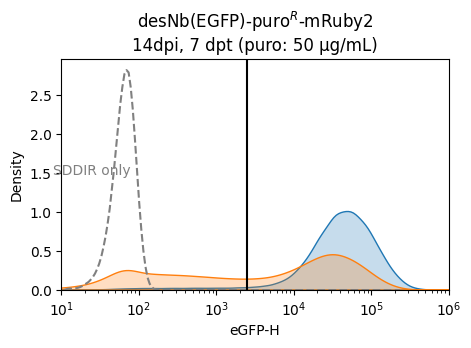

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))

# Threshold for Hb9::GFP
eGFP_H_thresh = 2.5*10**3

# Plot eGFP-H
x = 'eGFP-H'

sns.kdeplot(data=df.loc[(df['retro-puro'] == 'des-Nb') & (df['puro_conc'] == 50)],
        ax=ax, x=x,
        common_norm=False, log_scale=(True, False),
        fill=True)

sns.kdeplot(data=df.loc[(df['retro-puro'] == 'des-Nb') & (df['puro_conc'] == 0)],
        ax=ax, x=x,
        common_norm=False, log_scale=(True, False),
        fill=True)


# Plot 0 ug/mL ctrl
sns.kdeplot(data=df.loc[(df['retro-puro'] == 'SDDIR-only')],
        ax=ax, x=x,
        common_norm=False, log_scale=(True, False),
        fill=False, linestyle='--', color='grey')
ax.annotate('SDDIR only', (0.08, 0.5), color='grey', xycoords='axes fraction', ha='center')


# Plot threshold
ax.axvline(eGFP_H_thresh, 0, 1, color='black')

# Title
plt.title('desNb(EGFP)-puro$^{R}$-mRuby2\n14dpi, 7 dpt (puro: 50 µg/mL)')
# Adjust limits
eGFP_lim = (10, 1*10**6)
for sub_ax in plt.gcf().get_axes():
    sub_ax.set_xlim(eGFP_lim)


Creating summary dataframes

In [11]:
# Categorize iMNs based on eGFP_thresh
df['eGFP_cat'] = np.where(df['eGFP-H'] > eGFP_H_thresh, 'iMN', 'fib')

# Get total counts and percent of GFP-H+
group = ['retro-puro', 'puro_conc', 'biorep', 'scale']
count_df_reps = df.groupby([*group, 'well', 'eGFP_cat'])[
    'FSC-A'].count().unstack(fill_value=0).stack().rename('count') # Puts 0 if no GFP-H+ rather than dropping row
percent_df_reps = (count_df_reps*100/count_df_reps.groupby([*group, 'well']).transform('sum')).reset_index(name='percent')

# Get iMN yield per condition
data_iMN_count_reps = count_df_reps.reset_index(name='count')
data_total_count_reps = df.groupby([*group, 'well']).size().reset_index(name = 'total_count')

# Extract just the iMNs
data_iMN_percent_reps = percent_df_reps.loc[(percent_df_reps['eGFP_cat'] == 'iMN')]
data_iMN_count_reps = data_iMN_count_reps.loc[(data_iMN_count_reps['eGFP_cat'] == 'iMN')]

# Collapse to bio reps
# data_iMN_percent = data_iMN_percent_reps.groupby([*group]).mean().reset_index()
# data_iMN_count = data_iMN_count_reps.groupby([*group]).mean().reset_index()
data_iMN_percent = (
    data_iMN_percent_reps
    .groupby(group)
    .mean(numeric_only=True)
    .reset_index()
)

data_iMN_count = (
    data_iMN_count_reps
    .groupby(group)
    .mean(numeric_only=True)
    .reset_index()
)

data_total_count = (
    data_total_count_reps
    .groupby(group)
    .mean(numeric_only=True)
    .reset_index()
)

#calculating fold change relative to wtNb at 50 ug/mL puro
baseline = (
    data_iMN_percent
    .loc[
        (data_iMN_percent['retro-puro'] == 'WT-Nb') &
        (data_iMN_percent['puro_conc'] == 50)
    ]
    .groupby('scale')['percent']
    .mean()
)

data_iMN_percent['baseline'] = data_iMN_percent['scale'].map(baseline)

data_iMN_percent['fold_change'] = (
    data_iMN_percent['percent'] /
    data_iMN_percent['baseline']
)

data_purity_fc = (
    data_iMN_percent
    .groupby(group, as_index=False)['fold_change']
    .mean()
)

# Figure 5 iMN selection (6 well)

Figure 5D 6 well iMN yield

none_0 vs. none_10: ***
des-Nb_0 vs. des-Nb_50: **
Puro_0 vs. Puro_50: **
WT-Nb_0 vs. WT-Nb_50: ns
WT-Nb_50 vs. des-Nb_50: ns

Pairwise p-values:
------------------------------------------------------------
WT-Nb (0) vs WT-Nb (50): p = 0.3915 (ns)
des-Nb (0) vs des-Nb (50): p = 0.009875 (**)
Puro (0) vs Puro (50): p = 0.002114 (**)
WT-Nb (50) vs des-Nb (50): p = 0.06606 (ns)
none (0) vs none (10): p = 0.0004214 (***)


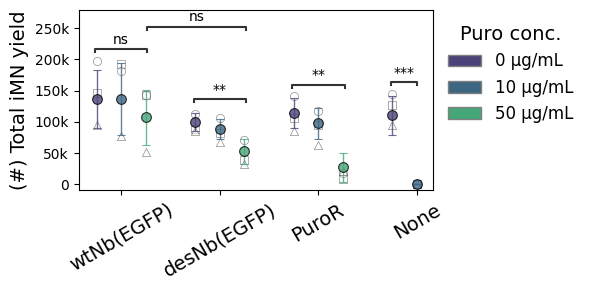

In [12]:
# General plotting params
x = 'retro-puro'
y = 'count'
order = ["WT-Nb", "des-Nb", 'Puro', "none"]
hue = 'puro_conc'
hue_order = [0, 10, 50]

# Plot iMN count of all cells

subset = data_iMN_count[
    (data_iMN_count['scale'] == '6-well') &
    (data_iMN_count['puro_conc'] != 100)
]

bio_means = (
    subset
    .groupby(['retro-puro', 'puro_conc', 'biorep'], as_index=False)[y]
    .mean()
)

summary = (
    bio_means
    .groupby(['retro-puro', 'puro_conc'], as_index=False)
    .agg(
        mean=(y, 'mean'),
        sd=(y, 'std')
    )
)

fig, ax = plt.subplots(1, 1, figsize=(6,3))

colors = dict(zip(hue_order, palette))

# positions
group_centers = np.arange(len(order))
offsets = np.linspace(-0.25, 0.25, len(hue_order))

markers = {1:'s', 2:'o', 3:'^', 0:'D'}

# Technical replicate dots (back layer)

for rep, marker in markers.items():

    rep_data = bio_means[bio_means.biorep == rep]

    for i, cond in enumerate(order):
        for j, puro in enumerate(hue_order):

            row = rep_data[
                (rep_data['retro-puro'] == cond) &
                (rep_data['puro_conc'] == puro)
            ]

            if row.empty:
                continue

            xloc = group_centers[i] + offsets[j]

            ax.scatter(
                xloc,
                row[y],
                marker=marker,
                s=35,
                facecolor='white',
                edgecolor='black',
                linewidth=0.5,
                alpha=alpha_biorep,
                zorder=2
            )

# Biological replicate mean dots (front layer)


for i, cond in enumerate(order):
    for j, puro in enumerate(hue_order):

        row = summary[
            (summary['retro-puro'] == cond) &
            (summary['puro_conc'] == puro)
        ]

        if row.empty:
            continue

        xloc = group_centers[i] + offsets[j]

        ax.errorbar(
            xloc,
            row['mean'].iloc[0],
            yerr=row['sd'].iloc[0],
            fmt='o',
            markersize=dot_size,
            color=colors[puro],
            alpha=alpha_main,
            mec='black',
            mew=0.8,
            capsize=3,
            linewidth=1,
            zorder=5
        )

#Formatting

ax.yaxis.set_label_text('(#) Total iMN yield', fontsize=yaxis_fontsize)
ax.xaxis.set_label_text('', fontsize=xaxis_fontsize)

ax.yaxis.set_major_formatter(
    matplotlib.ticker.FuncFormatter(
        lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'
    )
)


ax.set_xticks(group_centers)

label_map = {
    'WT-Nb': 'wtNb(EGFP)',
    'des-Nb': 'desNb(EGFP)',
    'Puro': 'PuroR',
    'none': 'None'
}

ax.set_xticklabels(
    [label_map[t] for t in order],
    rotation=30, fontsize=xaxis_fontsize
)


# Legend
legend_handles = [
    Patch(
        facecolor=colors[p],
        edgecolor='grey',
        label=f'{p} µg/mL'
    )
    for p in hue_order
]

ax.legend(
    handles=legend_handles,
    title='Puro conc.',
    loc='upper left',
    bbox_to_anchor=(1,1),
    frameon=False, fontsize=legend_fontsize, title_fontsize=legend_title_fontsize
)


# Statistical tests

pairs = [
         (('WT-Nb', 0), ('WT-Nb', 50)),
         (('des-Nb', 0), ('des-Nb', 50)),
         (('Puro', 0), ('Puro', 50)),
         (('WT-Nb', 50), ('des-Nb', 50)),
         (('none', 0), ('none', 10))
        

         ]

annotations = []
p_values = []

for (g1, h1), (g2, h2) in pairs:

    vals1 = subset.loc[
        (subset[x] == g1) &
        (subset[hue] == h1),
        y
    ]

    vals2 = subset.loc[
        (subset[x] == g2) &
        (subset[hue] == h2),
        y
    ]

    _, p = ttest_ind(vals1, vals2)

    if p < 1e-4:
        stars = "****"
    elif p < 1e-3:
        stars = "***"
    elif p < 1e-2:
        stars = "**"
    elif p < 0.05:
        stars = "*"
    else:
        stars = "ns"

    # fc = vals2.mean() / vals1.mean()
    p_values.append({
    "group1": g1,
    "hue1": h1,
    "group2": g2,
    "hue2": h2,
    "p": p,
    "stars": stars
})
    # annotations.append(f"{stars}\n{fc:.1f}×")
    annotations.append(f"{stars}")

annotator = Annotator(
    ax,
    pairs=pairs,
    data=subset,
    x=x,
    y=y,
    hue=hue,
    order=order,
    hue_order=hue_order,
)

annotator.configure(
    test='t-test_ind',
    text_format='full',
    loc='inside',
    line_height=0.02,
    text_offset=2
)

annotator.set_custom_annotations(annotations)
annotator.annotate()
print("\nPairwise p-values:")
print("-" * 60)

for result in p_values:
    print(
        f"{result['group1']} ({result['hue1']}) vs "
        f"{result['group2']} ({result['hue2']}): "
        f"p = {result['p']:.4g} ({result['stars']})"
    )

fig.tight_layout()

plottitle = 'Figure_5D_iMN_count.svg'
plt.savefig(rd.outfile(output_path_main/plottitle),bbox_inches='tight')

**Figure 5D 6 well iMN purity**

none_0 vs. none_10: ****
des-Nb_0 vs. des-Nb_50: ****
Puro_0 vs. Puro_50: **
WT-Nb_0 vs. WT-Nb_50: ***
WT-Nb_50 vs. des-Nb_50: **

Pairwise p-values:
------------------------------------------------------------
WT-Nb (0) vs WT-Nb (50): p = 0.0004641 (***)
des-Nb (0) vs des-Nb (50): p = 9.205e-06 (****)
Puro (0) vs Puro (50): p = 0.006689 (**)
WT-Nb (50) vs des-Nb (50): p = 0.003552 (**)
none (0) vs none (10): p = 7.411e-05 (****)


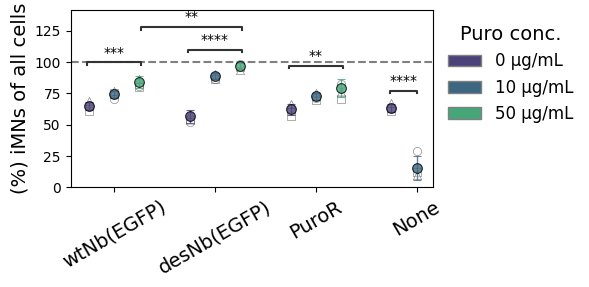

In [15]:
# General plotting params
x = 'retro-puro'
y = 'percent'
order = ["WT-Nb", "des-Nb", 'Puro', "none"]
hue = 'puro_conc'
hue_order = [0, 10, 50]

# Plot iMN percent of all cells

subset = data_iMN_percent[
    (data_iMN_percent['scale'] == '6-well') &
    (data_iMN_percent['puro_conc'] != 100)
]

bio_means = (
    subset
    .groupby(['retro-puro', 'puro_conc', 'biorep'], as_index=False)[y]
    .mean()
)

summary = (
    bio_means
    .groupby(['retro-puro', 'puro_conc'], as_index=False)
    .agg(
        mean=(y, 'mean'),
        sd=(y, 'std')
    )
)

fig, ax = plt.subplots(1, 1, figsize=(6,3))

colors = dict(zip(hue_order, palette))

# positions
group_centers = np.arange(len(order))
offsets = np.linspace(-0.25, 0.25, len(hue_order))

markers = {1:'s', 2:'o', 3:'^', 0:'D'}

# Technical replicate dots (back layer)

for rep, marker in markers.items():

    rep_data = bio_means[bio_means.biorep == rep]

    for i, cond in enumerate(order):
        for j, puro in enumerate(hue_order):

            row = rep_data[
                (rep_data['retro-puro'] == cond) &
                (rep_data['puro_conc'] == puro)
            ]

            if row.empty:
                continue

            xloc = group_centers[i] + offsets[j]

            ax.scatter(
                xloc,
                row[y],
                marker=marker,
                s=35,
                facecolor='white',
                edgecolor='black',
                linewidth=0.5,
                alpha=alpha_biorep,
                zorder=2
            )

# Biological replicate mean dots (front layer)


for i, cond in enumerate(order):
    for j, puro in enumerate(hue_order):

        row = summary[
            (summary['retro-puro'] == cond) &
            (summary['puro_conc'] == puro)
        ]

        if row.empty:
            continue

        xloc = group_centers[i] + offsets[j]

        ax.errorbar(
            xloc,
            row['mean'].iloc[0],
            yerr=row['sd'].iloc[0],
            fmt='o',
            markersize=dot_size,
            color=colors[puro],
            alpha=alpha_main,
            mec='black',
            mew=0.8,
            capsize=3,
            linewidth=1,
            zorder=5
        )

#Formatting

ax.yaxis.set_label_text('(%) iMNs of all cells', fontsize=yaxis_fontsize)
ax.xaxis.set_label_text('')

ax.yaxis.set_major_formatter(
    matplotlib.ticker.FuncFormatter(
        lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'
    )
)

ax.set_ylim(0,110)

ax.set_xticks(group_centers)

label_map = {
    'WT-Nb': 'wtNb(EGFP)',
    'des-Nb': 'desNb(EGFP)',
    'Puro': 'PuroR',
    'none': 'None'
}

ax.set_xticklabels(
    [label_map[t] for t in order],
    rotation=30, fontsize=xaxis_fontsize
)


# Legend
legend_handles = [
    Patch(
        facecolor=colors[p],
        edgecolor='grey',
        label=f'{p} µg/mL'
    )
    for p in hue_order
]

ax.legend(
    handles=legend_handles,
    title='Puro conc.',
    loc='upper left',
    bbox_to_anchor=(1,1),
    frameon=False, fontsize=legend_fontsize, title_fontsize=legend_title_fontsize
)


ax.axhline(
    100,
    color='grey',
    linestyle='--'
)


# Statistical tests

pairs = [
         (('WT-Nb', 0), ('WT-Nb', 50)),
         (('des-Nb', 0), ('des-Nb', 50)),
         (('Puro', 0), ('Puro', 50)),
         (('WT-Nb', 50), ('des-Nb', 50)),
         (('none', 0), ('none', 10))
        

         ]

annotations = []
p_values = []

for (g1, h1), (g2, h2) in pairs:

    vals1 = subset.loc[
        (subset[x] == g1) &
        (subset[hue] == h1),
        y
    ]

    vals2 = subset.loc[
        (subset[x] == g2) &
        (subset[hue] == h2),
        y
    ]

    _, p = ttest_ind(vals1, vals2)

    if p < 1e-4:
        stars = "****"
    elif p < 1e-3:
        stars = "***"
    elif p < 1e-2:
        stars = "**"
    elif p < 0.05:
        stars = "*"
    else:
        stars = "ns"

    # fc = vals2.mean() / vals1.mean()
    p_values.append({
    "group1": g1,
    "hue1": h1,
    "group2": g2,
    "hue2": h2,
    "p": p,
    "stars": stars
})
    # annotations.append(f"{stars}\n{fc:.1f}×")

    annotations.append(f"{stars}")


annotator = Annotator(
    ax,
    pairs=pairs,
    data=subset,
    x=x,
    y=y,
    hue=hue,
    order=order,
    hue_order=hue_order,
)

annotator.configure(
    test='t-test_ind',
    text_format='full',
    loc='inside',
    line_height=0.02,
    text_offset=2
)

annotator.set_custom_annotations(annotations)
annotator.annotate()
print("\nPairwise p-values:")
print("-" * 60)

for result in p_values:
    print(
        f"{result['group1']} ({result['hue1']}) vs "
        f"{result['group2']} ({result['hue2']}): "
        f"p = {result['p']:.4g} ({result['stars']})"
    )

fig.tight_layout()

plottitle = 'Figure_5D_iMN_purity.svg'
plt.savefig(rd.outfile(output_path_main/plottitle),bbox_inches='tight')

Figure 5D-F NBW FACS/DASIT Comparisons

In [16]:
# Base dir for data files
path = rd.datadir /'data'/'attune'/ 'nat_attune' / 'desNb-circuits' / "2025.11.26_DASIT-iMN-purify_1-3"

# Data path
cache_path_14dpi = rd.rootdir/'output' /'Figure_5'/'data_14dpi.gzip'

if cache_path_14dpi.exists():
    df_14dpi = pd.read_parquet(cache_path_14dpi)

else: 
    
    files = Path(path / 'export_singlets_14dpi').glob('*.csv')
    df_list = list()

    for i, file in enumerate(files):

        match = re.search('export_(?P<cond>.+)_(?P<purify>.+)_(?P<rep>\d)_Singlets.csv', file.name)

        # If no match
        if match is None:
            print(file.name, 'did not match anything')
            continue

        cond = match.group('cond')
        purify = match.group('purify')
        rep = match.group('rep')

        if purify[:4] == 'puro':
            puro = float(purify[4:])
            cond = "postPuro"
        else:
            puro = 0

        # Load as df and note header is on 0th row
        df = pd.read_csv(file, header=0)

        # Update columns in df with metadata from file name
        df['dpi'] = 14
        df['cond'] = cond
        df['purify'] = purify
        df['rep'] = int(rep)
        
        df_list.append(df)

    # Convert list of dfs into single df
    df_14dpi = pd.concat(df_list, ignore_index=True)

    # # Convert puro to int
    # df_all = df_all.astype({'puro': 'int'})

    # Shorten df
    channel_list = ['eGFP-H', 'dpi', 'cond', 'purify', 'rep']
    df_14dpi = df_14dpi.loc[:, channel_list]

    # Save shortened df
    df_14dpi.to_parquet(rd.outfile(cache_path_14dpi))

<>:17: SyntaxWarning: invalid escape sequence '\d'
<>:17: SyntaxWarning: invalid escape sequence '\d'
C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_50500\618070879.py:17: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('export_(?P<cond>.+)_(?P<purify>.+)_(?P<rep>\d)_Singlets.csv', file.name)


In [17]:
df_counts_14dpi = pd.read_excel(open(path/'2025.11.26_counts.xlsx', 'rb'), sheet_name='14 dpi summary') 

# Add in how many HG cells per 6well there is using hemocytometer data
for index, row in df_counts_14dpi.iterrows():

    df_counts_14dpi.loc[index, 'cond.purifyCond'] = row['cond'] + "." + row['purifyCond']
    df_counts_14dpi.loc[index, 'Hb9::EGFP+ [%]'] = row['Hb9::EGFP+ [frac]']*100
    df_counts_14dpi.loc[index, 'Total # cells'] = row['Total # cells [k]']*1e3
    df_counts_14dpi.loc[index, 'Cells per 6well'] = df_counts_14dpi.loc[index, 'Total # cells']/row['Total 6wells dissociated']
    df_counts_14dpi.loc[index, 'HG cells per 6well'] = df_counts_14dpi.loc[index, 'Cells per 6well']*row['Hb9::EGFP+ [frac]']
    df_counts_14dpi.loc[index, 'Hb9::EGFP+ recovery [%]'] = row['Hb9::EGFP+ recovery [%]']

df_counts_14dpi

,dpi,rep,cond,purifyCond,Total 6wells dissociated,Total # cells [k],Hb9::EGFP+ [frac],Hb9::EGFP+ recovery [%],cond.purifyCond,Hb9::EGFP+ [%],Total # cells,Cells per 6well,HG cells per 6well
0,14,1,DASIT,puro0,2,1100.000000,0.35,64.166667,DASIT.puro0,35.0,1.100000e+06,5.500000e+05,192500.0
1,14,1,DASIT,puro10,1,195.000000,0.70,45.500000,DASIT.puro10,70.0,1.950000e+05,1.950000e+05,136500.0
2,14,1,DASIT,puro50,2,316.666667,0.99,52.250000,DASIT.puro50,99.0,3.166667e+05,1.583333e+05,156750.0
3,14,1,DASIT,puro100,1,2.500000,0.88,0.733333,DASIT.puro100,88.0,2.500000e+03,2.500000e+03,2200.0
4,14,1,noReseed,preFACS,1,3287.500000,0.41,NaN,noReseed.preFACS,41.0,3.287500e+06,3.287500e+06,1347875.0
5,14,2,DASIT,puro0,2,925.000000,0.30,46.250000,DASIT.puro0,30.0,9.250000e+05,4.625000e+05,138750.0
6,14,2,DASIT,puro10,1,92.500000,0.77,23.741667,DASIT.puro10,77.0,9.250000e+04,9.250000e+04,71225.0
7,14,2,DASIT,puro50,2,225.000000,0.99,37.125000,DASIT.puro50,99.0,2.250000e+05,1.125000e+05,111375.0
8,14,2,DASIT,puro100,1,5.000000,0.89,1.483333,DASIT.puro100,89.0,5.000000e+03,5.000000e+03,4450.0
9,14,2,noReseed,preFACS,1,2112.500000,0.38,NaN,noReseed.preFACS,38.0,2.112500e+06,2.112500e+06,802750.0


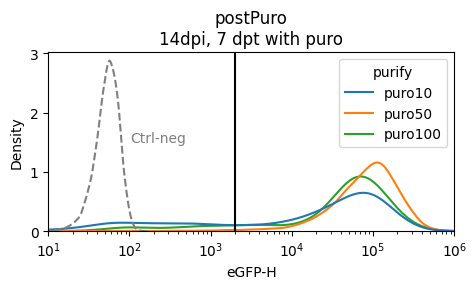

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))

# Threshold for Hb9::GFP
eGFP_H_thresh = 2e3

# Plot eGFP-H
x = 'eGFP-H'
cond = 'postPuro'
hue = 'purify'
hue_order = ['puro10', 'puro50', 'puro100']
rep = 1
sns.kdeplot(data=df_14dpi.loc[(df_14dpi['cond'] == cond) & (df_14dpi[x]>0) & (df_14dpi['rep']==rep)],
        ax=ax, x=x, hue=hue,
        hue_order=hue_order,
        common_norm=False, log_scale=(True, False),
        fill=False)


# Plot ctrl-neg
sns.kdeplot(data=df_14dpi.loc[(df_14dpi['cond'] == 'Ctrl-neg') & (df_14dpi[x]>0)],
        ax=ax, x=x,
        common_norm=False, log_scale=(True, False),
        fill=False, linestyle='--', color='grey')
ax.annotate('Ctrl-neg', (0.27, 0.5), color='grey', xycoords='axes fraction', ha='center')

# Plot threshold
ax.axvline(eGFP_H_thresh, 0, 1, color='black')

# Title
plt.title(f'{cond}\n14dpi, 7 dpt with puro')
# Adjust limits
eGFP_lim = (10, 1*10**6)
for sub_ax in plt.gcf().get_axes():
    sub_ax.set_xlim(eGFP_lim)

# Misc plotting stuff
fig.tight_layout()  # Helps improve white spacing

In [19]:
# Categorize iMNs based on eGFP_thresh
df_14dpi['eGFP_cat'] = np.where(df_14dpi['eGFP-H'] > eGFP_H_thresh, 'iMN', 'fib') 

# Get total counts and percent of GFP-H+
group = ['dpi', 'cond', 'purify']
count_df_reps_NBW = df_14dpi.groupby([*group, 'rep', 'eGFP_cat'])[
    'eGFP-H'].count().unstack(fill_value=0).stack().rename('count') # Puts 0 if no GFP-H+ rather than dropping row
data_iMN_percent_reps_NBW = (count_df_reps_NBW*100/count_df_reps_NBW.groupby([*group, 'rep']).transform('sum')).reset_index(name='percent')

# Extract just the iMNs
data_iMN_percent_reps_NBW = data_iMN_percent_reps_NBW.loc[(data_iMN_percent_reps_NBW['eGFP_cat'] == 'iMN')]

**Figure 5F Purity compared to FACS**

C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_50500\732595816.py:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_50500\732595816.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_50500\732595816.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label_dict[l] for l in order])


noReseed.noReseed-postFACS vs. DASIT.puro50: t-test independent samples with Bonferroni correction, P_val:1.603e-04 t=-1.379e+01


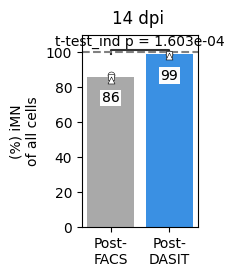

In [20]:
# General plotting params
x = 'cond.purifyCond'
y = 'Hb9::EGFP+ [%]'
order = ['noReseed.noReseed-postFACS', 'DASIT.puro50']
marker_list = ['o', 's', '^', 'D', 'P', 'X']   

label_dict = {'DASIT.puro50':'Post-\nDASIT', 'noReseed.noReseed-postFACS':'Post-\nFACS'}

palette_NBW = {'DASIT.puro50':'dodgerblue', 'noReseed.noReseed-postFACS':'darkgray'}


# Plot
fig, ax = plt.subplots(1, 1, figsize=(1.5,2.5))

sns.barplot(
    ax=ax, data=df_counts_14dpi,
    x=x, y=y,
    ci=None,
    order=order,
    palette=palette_NBW,
    alpha=1)

# Plot bio tech reps
for (j, rep) in enumerate(df_counts_14dpi.rep.unique()):
    sns.stripplot(
        ax=ax, data=df_counts_14dpi[(df_counts_14dpi.rep == rep)],
        x=x, y=y,
        order=order,
        dodge=True, marker=marker_list[j],
        color='white', size=5,
        edgecolor='black', linewidth=0.4)

# Add barplot labels
    for sub_ax in plt.gcf().get_axes():
        for i in sub_ax.containers:
            bar_labels = sub_ax.bar_label(i, fmt='%0.0f', padding=-20)
            for label in bar_labels:
                label.set_bbox(dict(facecolor='white', alpha=0.75, linewidth=0, pad=1))
                

ax.set_xticklabels([label_dict[l] for l in order])

# Add in stats
# Pairs for stats comp
pairs = [('DASIT.puro50', 'noReseed.noReseed-postFACS')]
annot = Annotator(ax=ax,
    data=df_counts_14dpi, pairs=pairs,
    x=x, y=y,
    order=order)
annot.configure(test='t-test_ind', comparisons_correction='Bonferroni', text_format='full', loc='inside', verbose=2) # Change full to stars for annotated output
annot.apply_test().annotate(line_offset_to_group=0)


# Formatting
ax.yaxis.set_label_text('(%) iMN\nof all cells')
ax.xaxis.set_label_text('')
ax.set_ylim([0, 110])
ax.axhline(100, 0, 1, color='grey', linestyle='--')

# Format
plt.suptitle(f'14 dpi')
plottitle = f'Figure_5F_bar.svg'
plt.savefig(rd.outfile(output_path_main/plottitle),bbox_inches='tight')

**Figure 5G iMN recovery compared to FACS**

C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_50500\544847773.py:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_50500\544847773.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_50500\544847773.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label_dict[l] for l in order])


noReseed.noReseed-postFACS vs. DASIT.puro50: t-test independent samples with Bonferroni correction, P_val:2.982e-03 t=-6.445e+00


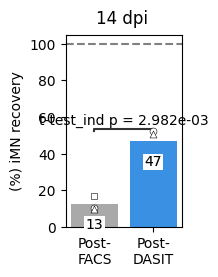

In [21]:
# General plotting params
x = 'cond.purifyCond'
y = 'Hb9::EGFP+ recovery [%]'
order = ['noReseed.noReseed-postFACS', 'DASIT.puro50']
marker_list = ['o', 's', '^', 'D', 'P', 'X']   

label_dict = {'DASIT.puro50':'Post-\nDASIT', 'noReseed.noReseed-postFACS':'Post-\nFACS'}

palette_NBW = {'DASIT.puro50':'dodgerblue', 'noReseed.noReseed-postFACS':'darkgray'}


# Plot
fig, ax = plt.subplots(1, 1, figsize=(1.5,2.5))

sns.barplot(
    ax=ax, data=df_counts_14dpi,
    x=x, y=y,
    ci=None,
    order=order,
    palette=palette_NBW,
    alpha=1)

# Plot bio tech reps
for (j, rep) in enumerate(df_counts_14dpi.rep.unique()):
    sns.stripplot(
        ax=ax, data=df_counts_14dpi[(df_counts_14dpi.rep == rep)],
        x=x, y=y,
        order=order,
        dodge=True, marker=marker_list[j],
        color='white', size=5,
        edgecolor='black', linewidth=0.4)

# Add barplot labels
    for sub_ax in plt.gcf().get_axes():
        for i in sub_ax.containers:
            bar_labels = sub_ax.bar_label(i, fmt='%0.0f', padding=-20)
            for label in bar_labels:
                label.set_bbox(dict(facecolor='white', alpha=0.75, linewidth=0, pad=1))
                

ax.set_xticklabels([label_dict[l] for l in order])

# Add in stats
# Pairs for stats comp
pairs = [('DASIT.puro50', 'noReseed.noReseed-postFACS')]
annot = Annotator(ax=ax,
    data=df_counts_14dpi, pairs=pairs,
    x=x, y=y,
    order=order)
annot.configure(test='t-test_ind', comparisons_correction='Bonferroni', text_format='full', loc='inside', verbose=2) # Change full to stars for star output vs p-value
annot.apply_test().annotate(line_offset_to_group=0)


# Formatting
ax.yaxis.set_label_text('(%) iMN recovery')
ax.xaxis.set_label_text('')
ax.set_ylim([0, 105])
ax.axhline(100, 0, 1, color='grey', linestyle='--')

# Format
plt.suptitle(f'14 dpi')
# fig.tight_layout()  # Helps improve white spacing
plottitle = 'Figure_5G_bar.svg'
plt.savefig(rd.outfile(output_path_main/plottitle),bbox_inches='tight')

# Figure S13 iMN select (6 well cont, 96 well)

## 96 well

Figure S13A 96 well total iMN yield

des-Nb_0 vs. des-Nb_50: ns
Puro_0 vs. Puro_50: ns
none_0 vs. none_50: ns
WT-Nb_0 vs. WT-Nb_50: ns
WT-Nb_50 vs. des-Nb_50: ns

Pairwise p-values:
------------------------------------------------------------
WT-Nb (0) vs WT-Nb (50): p = 0.0004641 (***)
des-Nb (0) vs des-Nb (50): p = 9.205e-06 (****)
Puro (0) vs Puro (50): p = 0.006689 (**)
WT-Nb (50) vs des-Nb (50): p = 0.003552 (**)
none (0) vs none (10): p = 7.411e-05 (****)
WT-Nb (0) vs WT-Nb (50): p = 0.3907 (ns)
des-Nb (0) vs des-Nb (50): p = 0.1568 (ns)
Puro (0) vs Puro (50): p = 0.09795 (ns)
WT-Nb (50) vs des-Nb (50): p = 0.1832 (ns)
none (0) vs none (50): p = 0.1781 (ns)


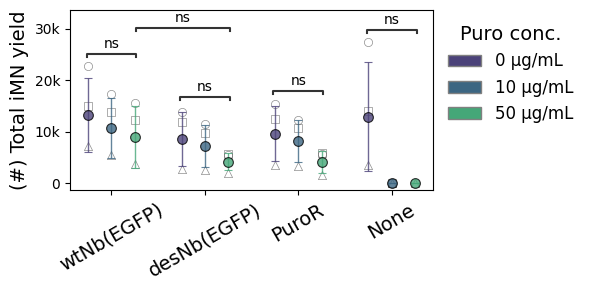

In [22]:

# General plotting params
x = 'retro-puro'
y = 'count'
order = ["WT-Nb", "des-Nb", 'Puro', "none"]
hue = 'puro_conc'
hue_order = [0, 10, 50]

# Plot iMN count of all cells

subset = data_iMN_count[
    (data_iMN_count['scale'] == '96-well') &
    (data_iMN_count['puro_conc'] != 100)
]

bio_means = (
    subset
    .groupby(['retro-puro', 'puro_conc', 'biorep'], as_index=False)[y]
    .mean()
)

summary = (
    bio_means
    .groupby(['retro-puro', 'puro_conc'], as_index=False)
    .agg(
        mean=(y, 'mean'),
        sd=(y, 'std')
    )
)

fig, ax = plt.subplots(1, 1, figsize=(6,3))

colors = dict(zip(hue_order, palette))

# positions
group_centers = np.arange(len(order))
offsets = np.linspace(-0.25, 0.25, len(hue_order))

markers = {1:'s', 2:'o', 3:'^', 0:'D'}

# Technical replicate dots (back layer)

for rep, marker in markers.items():

    rep_data = bio_means[bio_means.biorep == rep]

    for i, cond in enumerate(order):
        for j, puro in enumerate(hue_order):

            row = rep_data[
                (rep_data['retro-puro'] == cond) &
                (rep_data['puro_conc'] == puro)
            ]

            if row.empty:
                continue

            xloc = group_centers[i] + offsets[j]

            ax.scatter(
                xloc,
                row[y],
                marker=marker,
                s=35,
                facecolor='white',
                edgecolor='black',
                linewidth=0.5,
                alpha=alpha_biorep,
                zorder=2
            )

# Biological replicate mean dots (front layer)


for i, cond in enumerate(order):
    for j, puro in enumerate(hue_order):

        row = summary[
            (summary['retro-puro'] == cond) &
            (summary['puro_conc'] == puro)
        ]

        if row.empty:
            continue

        xloc = group_centers[i] + offsets[j]

        ax.errorbar(
            xloc,
            row['mean'].iloc[0],
            yerr=row['sd'].iloc[0],
            fmt='o',
            markersize=dot_size,
            color=colors[puro],
            alpha=alpha_main,
            mec='black',
            mew=0.8,
            capsize=3,
            linewidth=1,
            zorder=5
        )

#Formatting

ax.yaxis.set_label_text('(#) Total iMN yield', fontsize=yaxis_fontsize)
ax.xaxis.set_label_text('', fontsize=xaxis_fontsize)

ax.yaxis.set_major_formatter(
    matplotlib.ticker.FuncFormatter(
        lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'
    )
)

ax.set_xticks(group_centers)

label_map = {
    'WT-Nb': 'wtNb(EGFP)',
    'des-Nb': 'desNb(EGFP)',
    'Puro': 'PuroR',
    'none': 'None'
}

ax.set_xticklabels(
    [label_map[t] for t in order],
    rotation=30, fontsize =xaxis_fontsize
)


# Legend
legend_handles = [
    Patch(
        facecolor=colors[p],
        edgecolor='grey',
        label=f'{p} µg/mL'
    )
    for p in hue_order
]

ax.legend(
    handles=legend_handles,
    title='Puro conc.',
    loc='upper left',
    bbox_to_anchor=(1,1),
    frameon=False, fontsize=legend_fontsize, title_fontsize=legend_title_fontsize
)



# Statistical tests

pairs = [
         (('WT-Nb', 0), ('WT-Nb', 50)),
         (('des-Nb', 0), ('des-Nb', 50)),
         (('Puro', 0), ('Puro', 50)),
         (('WT-Nb', 50), ('des-Nb', 50)),
         (('none', 0), ('none', 50))
        

         ]

annotations = []

for (g1, h1), (g2, h2) in pairs:

    vals1 = subset.loc[
        (subset[x] == g1) &
        (subset[hue] == h1),
        y
    ]

    vals2 = subset.loc[
        (subset[x] == g2) &
        (subset[hue] == h2),
        y
    ]

    _, p = ttest_ind(vals1, vals2)

    if p < 1e-4:
        stars = "****"
    elif p < 1e-3:
        stars = "***"
    elif p < 1e-2:
        stars = "**"
    elif p < 0.05:
        stars = "*"
    else:
        stars = "ns"
    p_values.append({
    "group1": g1,
    "hue1": h1,
    "group2": g2,
    "hue2": h2,
    "p": p,
    "stars": stars
})
    # fc = vals2.mean() / vals1.mean()

    annotations.append(f"{stars}")


annotator = Annotator(
    ax,
    pairs=pairs,
    data=subset,
    x=x,
    y=y,
    hue=hue,
    order=order,
    hue_order=hue_order,
)

annotator.configure(
    test='t-test_ind',
    text_format='full',
    loc='inside',
    line_height=0.02,
    text_offset=2
)

annotator.set_custom_annotations(annotations)
annotator.annotate()
print("\nPairwise p-values:")
print("-" * 60)

for result in p_values:
    print(
        f"{result['group1']} ({result['hue1']}) vs "
        f"{result['group2']} ({result['hue2']}): "
        f"p = {result['p']:.4g} ({result['stars']})"
    )

fig.tight_layout()

plottitle = 'Figure_S13A_iMN_count.svg'
plt.savefig(rd.outfile(output_path_supp/plottitle),bbox_inches='tight')

**Figure S13A 96 well iMN purity**

des-Nb_0 vs. des-Nb_50: ****
Puro_0 vs. Puro_50: ***
none_0 vs. none_50: **
WT-Nb_0 vs. WT-Nb_50: ns
WT-Nb_50 vs. des-Nb_50: ***

Pairwise p-values:
------------------------------------------------------------
WT-Nb (0) vs WT-Nb (50): p = 0.3038 (ns)
des-Nb (0) vs des-Nb (50): p = 6.12e-07 (****)
Puro (0) vs Puro (50): p = 0.0003174 (***)
WT-Nb (50) vs des-Nb (50): p = 0.0003736 (***)
none (0) vs none (50): p = 0.001718 (**)


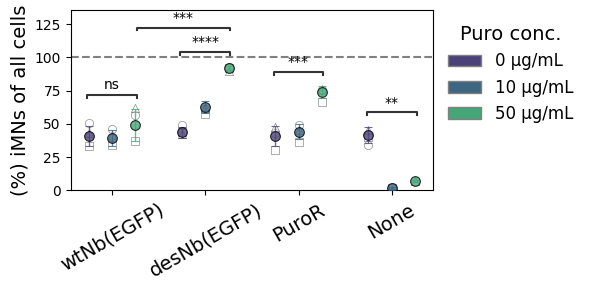

In [23]:
# General plotting params
x = 'retro-puro'
y = 'percent'
order = ["WT-Nb", "des-Nb", 'Puro', "none"]
hue = 'puro_conc'
hue_order = [0, 10, 50]

# Plot iMN percent of all cells

subset = data_iMN_percent[
    (data_iMN_percent['scale'] == '96-well') &
    (data_iMN_percent['puro_conc'] != 100)
]

bio_means = (
    subset
    .groupby(['retro-puro', 'puro_conc', 'biorep'], as_index=False)[y]
    .mean()
)

summary = (
    bio_means
    .groupby(['retro-puro', 'puro_conc'], as_index=False)
    .agg(
        mean=(y, 'mean'),
        sd=(y, 'std')
    )
)

fig, ax = plt.subplots(1, 1, figsize=(6,3))

colors = dict(zip(hue_order, palette))

# positions
group_centers = np.arange(len(order))
offsets = np.linspace(-0.25, 0.25, len(hue_order))

markers = {1:'s', 2:'o', 3:'^', 0:'D'}

# Technical replicate dots (back layer)

for rep, marker in markers.items():

    rep_data = bio_means[bio_means.biorep == rep]

    for i, cond in enumerate(order):
        for j, puro in enumerate(hue_order):

            row = rep_data[
                (rep_data['retro-puro'] == cond) &
                (rep_data['puro_conc'] == puro)
            ]

            if row.empty:
                continue

            xloc = group_centers[i] + offsets[j]

            ax.scatter(
                xloc,
                row[y],
                marker=marker,
                s=35,
                facecolor='white',
                edgecolor='black',
                linewidth=0.5,
                alpha=alpha_biorep,
                zorder=2
            )

# Biological replicate mean dots (front layer)


for i, cond in enumerate(order):
    for j, puro in enumerate(hue_order):

        row = summary[
            (summary['retro-puro'] == cond) &
            (summary['puro_conc'] == puro)
        ]

        if row.empty:
            continue

        xloc = group_centers[i] + offsets[j]

        ax.errorbar(
            xloc,
            row['mean'].iloc[0],
            yerr=row['sd'].iloc[0],
            fmt='o',
            markersize=dot_size,
            color=colors[puro],
            alpha=alpha_main,
            mec='black',
            mew=0.8,
            capsize=3,
            linewidth=1,
            zorder=5
        )

#Formatting

ax.yaxis.set_label_text('(%) iMNs of all cells', fontsize=yaxis_fontsize)
ax.xaxis.set_label_text('', fontsize=xaxis_fontsize)

ax.yaxis.set_major_formatter(
    matplotlib.ticker.FuncFormatter(
        lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'
    )
)

ax.set_ylim(0,110)

ax.set_xticks(group_centers)

label_map = {
    'WT-Nb': 'wtNb(EGFP)',
    'des-Nb': 'desNb(EGFP)',
    'Puro': 'PuroR',
    'none': 'None'
}

ax.set_xticklabels(
    [label_map[t] for t in order],
    rotation=30, fontsize=xaxis_fontsize
)


# Legend
legend_handles = [
    Patch(
        facecolor=colors[p],
        edgecolor='grey',
        label=f'{p} µg/mL'
    )
    for p in hue_order
]

ax.legend(
    handles=legend_handles,
    title='Puro conc.',
    loc='upper left',
    bbox_to_anchor=(1,1),
    frameon=False, fontsize=legend_fontsize, title_fontsize=legend_title_fontsize
)


ax.axhline(
    100,
    color='grey',
    linestyle='--'
)


# Statistical tests

pairs = [
         (('WT-Nb', 0), ('WT-Nb', 50)),
         (('des-Nb', 0), ('des-Nb', 50)),
         (('Puro', 0), ('Puro', 50)),
         (('WT-Nb', 50), ('des-Nb', 50)),
         (('none', 0), ('none', 50))
        

         ]

annotations = []
p_values = []

for (g1, h1), (g2, h2) in pairs:

    vals1 = subset.loc[
        (subset[x] == g1) &
        (subset[hue] == h1),
        y
    ]

    vals2 = subset.loc[
        (subset[x] == g2) &
        (subset[hue] == h2),
        y
    ]

    _, p = ttest_ind(vals1, vals2)

    if p < 1e-4:
        stars = "****"
    elif p < 1e-3:
        stars = "***"
    elif p < 1e-2:
        stars = "**"
    elif p < 0.05:
        stars = "*"
    else:
        stars = "ns"
    p_values.append({
    "group1": g1,
    "hue1": h1,
    "group2": g2,
    "hue2": h2,
    "p": p,
    "stars": stars
})
    annotations.append(f"{stars}")


annotator = Annotator(
    ax,
    pairs=pairs,
    data=subset,
    x=x,
    y=y,
    hue=hue,
    order=order,
    hue_order=hue_order,
)

annotator.configure(
    test='t-test_ind',
    text_format='full',
    loc='inside',
    line_height=0.02,
    text_offset=2
)

annotator.set_custom_annotations(annotations)
annotator.annotate()
print("\nPairwise p-values:")
print("-" * 60)

for result in p_values:
    print(
        f"{result['group1']} ({result['hue1']}) vs "
        f"{result['group2']} ({result['hue2']}): "
        f"p = {result['p']:.4g} ({result['stars']})"
    )

fig.tight_layout()

plottitle = 'Figure_S13A_iMN_purity.svg'
plt.savefig(rd.outfile(output_path_supp/plottitle),bbox_inches='tight')

Figure S13A purity fold change w.r.t. WT-Nb at 50 ug/mL

des-Nb_0 vs. des-Nb_50: ****
Puro_0 vs. Puro_50: ***
none_0 vs. none_50: **
WT-Nb_0 vs. WT-Nb_50: ns
WT-Nb_50 vs. des-Nb_50: ***

Pairwise p-values:
------------------------------------------------------------
WT-Nb (0) vs WT-Nb (50): p = 0.3038 (ns)
des-Nb (0) vs des-Nb (50): p = 6.12e-07 (****)
Puro (0) vs Puro (50): p = 0.0003174 (***)
WT-Nb (50) vs des-Nb (50): p = 0.0003736 (***)
none (0) vs none (50): p = 0.001718 (**)


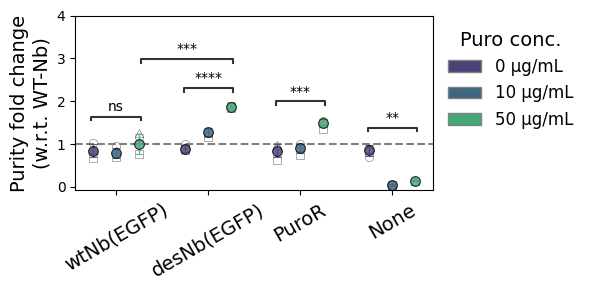

In [24]:
# General plotting params
x = 'retro-puro'
y = 'fold_change'
order = ["WT-Nb", "des-Nb", 'Puro', "none"]
hue = 'puro_conc'
hue_order = [0, 10, 50]

# Plot iMN count of all cells

subset = data_purity_fc[
    (data_purity_fc['scale'] == '96-well') &
    (data_purity_fc['puro_conc'] != 100)
]

bio_means = (
    subset
    .groupby(['retro-puro', 'puro_conc', 'biorep'], as_index=False)[y]
    .mean()
)

summary = (
    bio_means
    .groupby(['retro-puro', 'puro_conc'], as_index=False)
    .agg(
        mean=(y, 'mean'),
        sd=(y, 'std')
    )
)

fig, ax = plt.subplots(1, 1, figsize=(6,3))

colors = dict(zip(hue_order, palette))

# positions
group_centers = np.arange(len(order))
offsets = np.linspace(-0.25, 0.25, len(hue_order))

markers = {1:'s', 2:'o', 3:'^', 0:'D'}

# Technical replicate dots (back layer)

for rep, marker in markers.items():

    rep_data = bio_means[bio_means.biorep == rep]

    for i, cond in enumerate(order):
        for j, puro in enumerate(hue_order):

            row = rep_data[
                (rep_data['retro-puro'] == cond) &
                (rep_data['puro_conc'] == puro)
            ]

            if row.empty:
                continue

            xloc = group_centers[i] + offsets[j]

            ax.scatter(
                xloc,
                row[y],
                marker=marker,
                s=35,
                facecolor='white',
                edgecolor='black',
                linewidth=0.5,
                alpha=alpha_biorep,
                zorder=2
            )

# Biological replicate mean dots (front layer)


for i, cond in enumerate(order):
    for j, puro in enumerate(hue_order):

        row = summary[
            (summary['retro-puro'] == cond) &
            (summary['puro_conc'] == puro)
        ]

        if row.empty:
            continue

        xloc = group_centers[i] + offsets[j]

        ax.errorbar(
            xloc,
            row['mean'].iloc[0],
            yerr=row['sd'].iloc[0],
            fmt='o',
            markersize=dot_size,
            color=colors[puro],
            alpha=alpha_main,
            mec='black',
            mew=0.8,
            capsize=3,
            linewidth=1,
            zorder=5
        )

#Formatting

ax.yaxis.set_label_text('Purity fold change\n(w.r.t. WT-Nb)', fontsize=yaxis_fontsize)
ax.xaxis.set_label_text('')

ax.yaxis.set_major_formatter(
    matplotlib.ticker.FuncFormatter(
        lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'
    )
)

ax.axhline(1, 0, 1, color='grey', linestyle='--')
ax.set_yticks([0, 1, 2, 3, 4])

ax.set_xticks(group_centers)

label_map = {
    'WT-Nb': 'wtNb(EGFP)',
    'des-Nb': 'desNb(EGFP)',
    'Puro': 'PuroR',
    'none': 'None'
}

ax.set_xticklabels(
    [label_map[t] for t in order],
    rotation=30, fontsize=xaxis_fontsize
)


# Legend
legend_handles = [
    Patch(
        facecolor=colors[p],
        edgecolor='grey',
        label=f'{p} µg/mL'
    )
    for p in hue_order
]

ax.legend(
    handles=legend_handles,
    title='Puro conc.',
    loc='upper left',
    bbox_to_anchor=(1,1),
    frameon=False, fontsize=legend_fontsize, title_fontsize=legend_title_fontsize
)



# Statistical tests

pairs = [
         (('WT-Nb', 0), ('WT-Nb', 50)),
         (('des-Nb', 0), ('des-Nb', 50)),
         (('Puro', 0), ('Puro', 50)),
         (('WT-Nb', 50), ('des-Nb', 50)),
         (('none', 0), ('none', 50))
        

         ]

annotations = []
p_values = []

for (g1, h1), (g2, h2) in pairs:

    vals1 = subset.loc[
        (subset[x] == g1) &
        (subset[hue] == h1),
        y
    ]

    vals2 = subset.loc[
        (subset[x] == g2) &
        (subset[hue] == h2),
        y
    ]

    _, p = ttest_ind(vals1, vals2)

    if p < 1e-4:
        stars = "****"
    elif p < 1e-3:
        stars = "***"
    elif p < 1e-2:
        stars = "**"
    elif p < 0.05:
        stars = "*"
    else:
        stars = "ns"

    fc = vals2.mean() / vals1.mean()
    p_values.append({
    "group1": g1,
    "hue1": h1,
    "group2": g2,
    "hue2": h2,
    "p": p,
    "stars": stars
})
    # annotations.append(f"{stars}\n{fc:.1f}×")
    annotations.append(f"{stars}")


annotator = Annotator(
    ax,
    pairs=pairs,
    data=subset,
    x=x,
    y=y,
    hue=hue,
    order=order,
    hue_order=hue_order,
)

annotator.configure(
    test='t-test_ind',
    text_format='full',
    loc='inside',
    line_height=0.02,
    text_offset=2
)

annotator.set_custom_annotations(annotations)
annotator.annotate()
print("\nPairwise p-values:")
print("-" * 60)

for result in p_values:
    print(
        f"{result['group1']} ({result['hue1']}) vs "
        f"{result['group2']} ({result['hue2']}): "
        f"p = {result['p']:.4g} ({result['stars']})"
    )

fig.tight_layout()

plottitle = 'Figure_S13A_iMN_purity_fc.svg'
plt.savefig(rd.outfile(output_path_supp/plottitle),bbox_inches='tight')

## 6 well scale

In [25]:
#loading NBW data for FACS/DASIT comparison
# Base dir for data files
path = rd.datadir /'data'/'attune'/ 'nat_attune' / 'desNb-circuits' / "2025.11.26_DASIT-iMN-purify_1-3"

# Data path
cache_path_7dpi = rd.rootdir/'output'/'Figure_5'/'data.gzip'

if cache_path_7dpi.exists():
    df_7dpi = pd.read_parquet(cache_path_7dpi)

else: 
    
    files = Path(path / 'export_singlets_7dpi').glob('*.csv')
    df_list = list()

    for i, file in enumerate(files):

        print(file.name)

        match = re.search('export_(?P<cond>.+)_Singlets.csv', file.name)

        # If no match
        if match is None:
            print(file.name, 'did not match anything')
            continue

        cond = match.group('cond')

        # Load as df and note header is on 0th row
        df = pd.read_csv(file, header=0)

        # Update columns in df with metadata from file name
        if cond == 'Ctrl-neg':
            rep = 0
        elif cond[:3] == 'rep':
            rep = int(cond[3])
            cond = 'main'
            
        df['dpi'] = 7
        df['cond'] = cond
        df['rep'] = rep

        df_list.append(df)

    # Convert list of dfs into single df
    df_7dpi = pd.concat(df_list, ignore_index=True)

    # Shorten df
    channel_list = ['eGFP-H', 'dpi', 'cond', 'rep']
    df_7dpi = df_7dpi.loc[:, channel_list]

    # Save shortened df
    df_7dpi.to_parquet(rd.outfile(cache_path_7dpi))


In [26]:
df_counts_7dpi = pd.read_excel(open(path/'2025.11.26_counts.xlsx', 'rb'), sheet_name='7 dpi summary') 

# Add in how many HG cells per 6well there is using hemocytometer data
for index, row in df_counts_7dpi.iterrows():

    df_counts_7dpi.loc[index, 'percent Hb9::EGFP+'] = row['Hb9::EGFP+ [frac]']*100
    df_counts_7dpi.loc[index, 'Cells per 6well'] = row['Cells per 6well [mil]']*1e6
    df_counts_7dpi.loc[index, 'HG cells per 6well [mil]'] = row['Cells per 6well [mil]']*row['Hb9::EGFP+ [frac]']


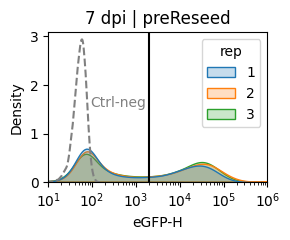

In [27]:
fig, ax = plt.subplots(1, 1, figsize=(3, 2.5))

# Threshold for Hb9::GFP
eGFP_H_thresh = 2e3
hue = 'rep'
palette = 'tab10'

# Plot eGFP-H
x = 'eGFP-H'
sns.kdeplot(data=df_7dpi.loc[(df_7dpi['cond'] != 'Ctrl-neg') & (df_7dpi[x]>0)], # (df_7dpi['rep'] == 1) & 
        ax=ax, x=x, hue=hue,
        common_norm=False, log_scale=(True, False), palette=palette,
        fill=True)


# Plot ctrl-neg
sns.kdeplot(data=df_7dpi.loc[(df_7dpi['cond'] == 'Ctrl-neg') & (df_7dpi[x]>0)],
        ax=ax, x=x,
        common_norm=False, log_scale=(True, False),
        fill=False, linestyle='--', color='grey')
ax.annotate('Ctrl-neg', (0.32, 0.5), color='grey', xycoords='axes fraction', ha='center')

# Plot threshold
ax.axvline(eGFP_H_thresh, 0, 1, color='black')

# Title
plt.title(f'7 dpi | preReseed')
# Adjust limits
eGFP_lim = (10, 1*10**6)
for sub_ax in plt.gcf().get_axes():
    sub_ax.set_xlim(eGFP_lim)

# Misc plotting stuff
fig.tight_layout()  # Helps improve white spacing

Make new df that is split by cell type (HG+ vs. all) for plotting purposes

In [28]:
# Make a new df split by cell type for plotting
df_counts_7dpi_HG = df_counts_7dpi.copy()
df_counts_7dpi_HG.loc[:, 'cellType'] = 'EGFP+'
df_counts_7dpi_all = df_counts_7dpi.copy()
df_counts_7dpi_all.loc[:, 'cellType'] = 'All'

df_counts_7dpi_split = pd.concat([df_counts_7dpi_all, df_counts_7dpi_HG], ignore_index=True)
df_counts_7dpi_split

# Merge wih data from counts
for index, row in df_counts_7dpi_split.iterrows():
    if row['cellType'] == 'EGFP+':
        df_counts_7dpi_split.loc[index, 'Cells per 6well [mil]'] = row['Cells per 6well [mil]']*row['Hb9::EGFP+ [frac]']

df_counts_7dpi_split.loc[:, 'Cells per 6well'] = df_counts_7dpi_split.loc[:, 'Cells per 6well [mil]']*1e6 

df_counts_7dpi_split

,dpi,rep,cond,purifyCond,Total 6wells dissociated,Cells per 6well [mil],Hb9::EGFP+ [frac],percent Hb9::EGFP+,Cells per 6well,HG cells per 6well [mil],cellType
0,7,1,main,preReseed,6,3.216667,0.42,42.0,3.216667e+06,1.351000,All
1,7,2,main,preReseed,6,2.900000,0.46,46.0,2.900000e+06,1.334000,All
2,7,3,main,preReseed,6,2.316667,0.47,47.0,2.316667e+06,1.088833,All
3,7,1,main,preReseed,6,1.351000,0.42,42.0,1.351000e+06,1.351000,EGFP+
4,7,2,main,preReseed,6,1.334000,0.46,46.0,1.334000e+06,1.334000,EGFP+
5,7,3,main,preReseed,6,1.088833,0.47,47.0,1.088833e+06,1.088833,EGFP+


Text(0.5, 0.98, '7 dpi')

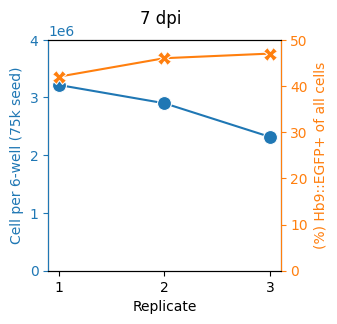

In [29]:
# General plotting params
x = 'rep'

# Plot
fig, ax1 = plt.subplots(1, 1, figsize=(3,3))

y1 = 'Cells per 6well'
color1 = 'tab:blue'
sns.lineplot(
    ax=ax1, data=df_counts_7dpi,
    x=x, y=y1,
    marker='o', markersize=10, color=color1)

y2 = 'percent Hb9::EGFP+'
color2 = 'tab:orange'
ax2 = ax1.twinx()
sns.lineplot(
    ax=ax2, data=df_counts_7dpi,
    x=x, y=y2,
    marker='X', markersize=10, color=color2, legend=False)

ax1.yaxis.set_label_text('Cell per 6-well (75k seed)', color=color1)
ax1.tick_params(axis='y', colors=color1)
# ax1.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1e6:.0f}e6'))
ax1.set_yticks(np.arange(0, 4.1e6, 1e6))
ax1.set_ylim([0, 4e6])

ax2.yaxis.set_label_text('(%) Hb9::EGFP+ of all cells', color=color2)
ax2.tick_params(axis='y', colors=color2)

ax2.spines['left'].set_color(color1)
ax2.spines['right'].set_color(color2)
ax2.set_ylim([0, 50])

ax1.set_xticks(np.arange(1, 4, 1))
ax1.set_xlabel('Replicate')

plt.suptitle(f'7 dpi')

**Figure S13B NBW Cells seeded**

C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_50500\3172193010.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_50500\3172193010.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


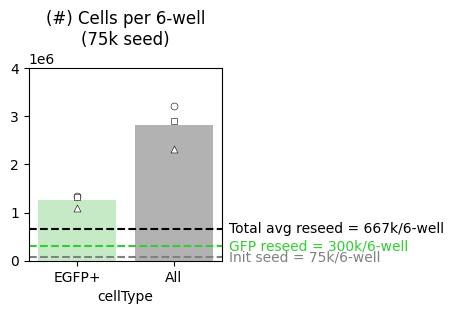

In [30]:
# General plotting params
x = 'cellType'
y = 'Cells per 6well'
order = ['EGFP+', 'All']
marker_list = ['o', 's', '^', 'D', 'P', 'X']   

palette = {'All': 'black', 'EGFP+': 'limegreen'}

# Plot
fig, ax = plt.subplots(1, 1, figsize=(2.5, 2.5))

sns.barplot(
    ax=ax, data=df_counts_7dpi_split, 
    x=x, y=y, 
    order=order,
    ci=None,
    palette=palette, alpha=0.3)

# Plot bio tech reps
for (j, rep) in enumerate(df_counts_7dpi_split.rep.unique()):
    sns.stripplot(
        ax=ax, data=df_counts_7dpi_split[(df_counts_7dpi_split.rep == rep)],
        x=x, y=y,
        order=order,
        dodge=True, marker=marker_list[j],
        color='white', size=5,
        edgecolor='black', linewidth=0.4)

ax.yaxis.set_label_text('')
ax.set_ylim([0, 3.5e6])
ax.set_yticks(np.arange(0, 4e6+1, 1e6))

# Annotate lines
init_seed = 75e3 # 75k MEFs/6-well init seed
GFP_reseed = 0.3e6 # 300k Hb9::EGFP+/6-well reseed at 7 dpi
frac_EGFP = df_counts_7dpi.loc[:,'Hb9::EGFP+ [frac]'].mean()
total_reseed = GFP_reseed/frac_EGFP # How many total cells/6-well reseed at 7 dpi
init_seed_color = 'grey'
GFP_reseed_color = 'limegreen'
total_reseed_color = 'black'
ax.axhline(init_seed, 0, 1, color=init_seed_color, linestyle='--')
ax.axhline(GFP_reseed, 0, 1, color=GFP_reseed_color, linestyle='--')
ax.axhline(total_reseed, 0, 1, color=total_reseed_color, linestyle='--')

ax.annotate(f'Init seed = {init_seed/1e3:.0f}k/6-well', 
            xy=(1, init_seed), xycoords=('axes fraction', 'data'),
            xytext=(5, 0), textcoords='offset points',
            color=init_seed_color, verticalalignment='center', horizontalalignment='left')
ax.annotate(f'GFP reseed = {GFP_reseed/1e3:.0f}k/6-well', 
            xy=(1, GFP_reseed), xycoords=('axes fraction', 'data'),
            xytext=(5, 0), textcoords='offset points',
            color=GFP_reseed_color, verticalalignment='center', horizontalalignment='left')
ax.annotate(f'Total avg reseed = {total_reseed/1e3:.0f}k/6-well',
            xy=(1, total_reseed), xycoords=('axes fraction', 'data'),
            xytext=(5, 0), textcoords='offset points',
            color=total_reseed_color, verticalalignment='center', horizontalalignment='left')



plt.title('(#) Cells per 6-well\n(75k seed)')

plottitle = 'Figure_S13B_bars.svg'
plt.savefig(rd.outfile(output_path_supp/plottitle),bbox_inches='tight')

**Figure S13D (left)**

C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_50500\3130914866.py:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


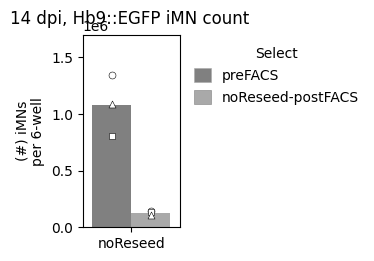

In [31]:
# General plotting params
x = 'cond'
y = 'HG cells per 6well'
order = ['noReseed']
hue = 'purifyCond'
hue_order = ['preFACS', 'noReseed-postFACS']
marker_list = ['o', 's', '^', 'D', 'P', 'X']   
palette = {'preFACS':'grey', 'noReseed-postFACS':'darkgray'}

label_dict = {'preFACS':'preFACS', 'noReseed-postFACS':'postFACS'}

# Plot
fig, ax = plt.subplots(1, 1, figsize=(1.25,2.5))

sns.barplot(
    ax=ax, data=df_counts_14dpi,
    x=x, y=y, hue=hue,
    ci=None,
    order=order, hue_order=hue_order,
    palette=palette, alpha=1)

# Plot bio tech reps
for (j, rep) in enumerate(df_counts_14dpi.rep.unique()):
    sns.stripplot(
        ax=ax, data=df_counts_14dpi[(df_counts_14dpi.rep == rep)],
        x=x, y=y, hue=hue,
        order=order, hue_order=hue_order,
        dodge=True, marker=marker_list[j],
        palette={hue:'white' for hue in hue_order}, size=5,
        edgecolor='black', linewidth=0.4)

# legend
legend_elements = [
    Patch(facecolor='grey', edgecolor='darkgrey', linewidth=0.4,
          label='preFACS'),
    Patch(facecolor='darkgray', edgecolor='grey', linewidth=0.4,
          label='noReseed-postFACS')
]

# Remove existing legend
if ax.get_legend() is not None:
    ax.get_legend().remove()

ax.legend(
    handles=legend_elements,
    title='Select',
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    frameon=False,
    handlelength=1.2,
    handleheight=1.2
)
 

# Formatting
ax.yaxis.set_label_text('(#) iMNs\nper 6-well')
ax.xaxis.set_label_text('')
ax.set_ylim([0, 1.7e6])


# Format
plt.suptitle(f'14 dpi, Hb9::EGFP iMN count')
plottitle = f'Figure_S13D_count.svg'
plt.savefig(rd.outfile(output_path_supp/plottitle),bbox_inches='tight')

**Figure S13 D (right)**

C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_50500\2287339595.py:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


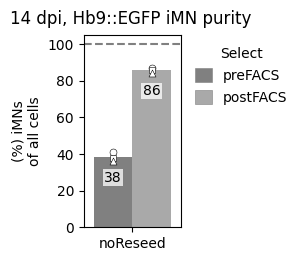

In [32]:
# General plotting params
x = 'cond'
y = 'Hb9::EGFP+ [%]'
order = ['noReseed']
hue = 'purifyCond'
hue_order = ['preFACS', 'noReseed-postFACS']
marker_list = ['o', 's', '^', 'D', 'P', 'X']   
palette = {'preFACS':'grey', 'noReseed-postFACS':'darkgray'}

label_dict = {'preFACS':'preFACS', 'noReseed-postFACS':'postFACS'}

# Plot
fig, ax = plt.subplots(1, 1, figsize=(1.25,2.5))

sns.barplot(
    ax=ax, data=df_counts_14dpi,
    x=x, y=y, hue=hue,
    ci=None,
    order=order, hue_order=hue_order,
    palette=palette, alpha=1)

# Plot bio tech reps
for (j, rep) in enumerate(df_counts_14dpi.rep.unique()):
    sns.stripplot(
        ax=ax, data=df_counts_14dpi[(df_counts_14dpi.rep == rep)],
        x=x, y=y, hue=hue,
        order=order, hue_order=hue_order,
        dodge=True, marker=marker_list[j],
        palette={hue:'white' for hue in hue_order}, size=5,
        edgecolor='black', linewidth=0.4)

# legend
legend_elements = [
    Patch(facecolor='grey', edgecolor='grey', linewidth=0.4,
          label='preFACS'),
    Patch(facecolor='darkgray', edgecolor='grey', linewidth=0.4,
          label='postFACS')
]

# Remove existing legend
if ax.get_legend() is not None:
    ax.get_legend().remove()

ax.legend(
    handles=legend_elements,
    title='Select',
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    frameon=False,
    handlelength=1.2,
    handleheight=1.2
)

# Add barplot labels
for sub_ax in plt.gcf().get_axes():
    for i in sub_ax.containers:
        bar_labels = sub_ax.bar_label(i, fmt='%0.0f', padding=-20)
        for label in bar_labels:
            label.set_bbox(dict(facecolor='white', alpha=0.75, linewidth=0, pad=1))   

# Formatting
ax.yaxis.set_label_text('(%) iMNs\nof all cells')
ax.xaxis.set_label_text('')
# # ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'))
ax.set_ylim([0, 105])
ax.axhline(100, 0, 1, color='grey', linestyle='--')

# Format
plt.suptitle(f'14 dpi, Hb9::EGFP iMN purity')
plottitle = f'Figure_S13D_purity.svg'
plt.savefig(rd.outfile(output_path_supp/plottitle),bbox_inches='tight') 

Loading data for S13E

In [33]:
# Directories
datadir = rd.datadir/'data'/'attune'/'nat_attune'/'Reprogram_opt'/'2024.09.27_postsort_EdU-14dpi_0dps'/'export_singlets'

# Store all data in list of dfs which will be converted to df at end
data_14dpi_EdU = list()

# Get all CVs
files = Path(datadir).glob('*.csv') 
for i, file in enumerate(files):

    # Extract metadata from csv title
    match = re.search(
        'export_(?P<cond>.+)_(?P<rep>\d)_Singlets.csv', file.name)

    df = pd.read_csv(file, header=0)
    df['rep'] = int(match.group('rep'))
    df['cond'] = match.group('cond')
    
    data_14dpi_EdU.append(df)


# Convert list of dfs into single df
data_14dpi_EdU = pd.concat(data_14dpi_EdU, ignore_index=True)

# Remove negative data
data_14dpi_EdU_all = data_14dpi_EdU.loc[(data_14dpi_EdU['eGFP-H'] > 0)]

# Split into cond and non
data_14dpi_EdU = data_14dpi_EdU_all.loc[data_14dpi_EdU_all.cond == 'NILRIDD']
data_14dpi_EdU_ctrl = data_14dpi_EdU_all.loc[data_14dpi_EdU_all.cond == 'Ctrl-neg']

<>:13: SyntaxWarning: invalid escape sequence '\d'
<>:13: SyntaxWarning: invalid escape sequence '\d'
C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_50500\1727407881.py:13: SyntaxWarning: invalid escape sequence '\d'
  'export_(?P<cond>.+)_(?P<rep>\d)_Singlets.csv', file.name)


In [34]:
# Base dir for data files
base_datadir = rd.datadir /'data'/'attune'/ "nat_attune" / "desNb-circuits" / "2025.03.10_desNb-reseed_14dpi"

# List of puro conc + directories
dir_list = ['0nguL', '48-96-nguL']

# Store all data in list of dfs which will be converted to df at end
df_all = list()
# for (dir, puro) in dirs.items():
for dir in dir_list:

     # Load as df and note header is on 0th row
    df = rd.flow.load_csv_with_metadata(
        base_datadir/dir/'export_singlets', base_datadir/f'well_metadata_{dir}.yaml')

    df_all.append(df)

# Convert list of dfs into single df
df_all = pd.concat(df_all, ignore_index=True)

# Remove negative data
df = df_all.loc[( df_all["eGFP-A"] > 0) & (df_all["mRuby2-A"] > 0)]

# Convert puro to int
df = df.astype({'puro': 'int'})
# Just get desNb(EGFP)
df_desNb = df.loc[df.cond == 'desNb(EGFP)']
# Get rid of rep 1 (cell death)
df_desNb = df_desNb.loc[df_desNb.rep != 1]

In [35]:
# Base dir for data files
base_datadir = rd.datadir /'data'/'attune'/ "nat_attune" / "desNb-circuits" / "2024.01.05_seedtitrate_7dpt"
# figure path

# List of puro conc + directories
dirs = {'0ugmL': 0, '96ugmL':96}

# Store all data in list of dfs which will be converted to df at end
df_all = list()
for (dir, puro) in dirs.items():

     # Load as df and note header is on 0th row
    df = rd.flow.load_csv_with_metadata(
        base_datadir/dir/'export_singlets', base_datadir/'well_metadata.yaml')

    df['puro'] = puro
    df_all.append(df)

# Convert list of dfs into single df
df_all = pd.concat(df_all, ignore_index=True)

# Remove negative data
df = df_all.loc[( df_all["eGFP-A"] > 0) & (df_all["mRuby2-A"] > 0)]

# Convert puro to int
df = df.astype({'puro': 'int'})

# Just get desNb(EGFP) and rename to match desNb(EGFP)
df_desNb_1 = df.loc[df.cond == 'desNb-puro-mRuby2']
df_desNb_1['cond'] = 'desNb(EGFP)'
# Just get 2.5k seed to match
df_desNb_1 = df_desNb_1.loc[df_desNb_1.seedNum == '2.5k']
df_desNb_1['rep'] = 1
# Get rid of unnecessary columns
df_desNb_1.drop(['celltype', 'seedNum'], axis='columns', inplace=True)

C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_50500\385416246.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_desNb_1['cond'] = 'desNb(EGFP)'


In [36]:
data_list = [data_14dpi_EdU_ctrl[(data_14dpi_EdU_ctrl['cond'] == 'Ctrl-neg')], data_14dpi_EdU, df_desNb.loc[df_desNb.puro == 96], df_desNb_1.loc[df_desNb_1.puro == 96],]
data_both = pd.concat(data_list, ignore_index=True)

**Figure S13E - single cell distribution**

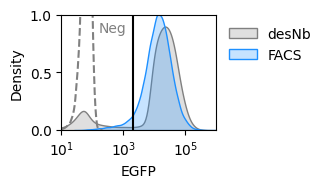

In [37]:
# Plot eGFP-H
fig, ax = plt.subplots(1, 1, figsize=(2, 1.5))
x = 'eGFP-H'
hue = 'cond'
palette = {'desNb(EGFP)': 'dodgerblue', 'NILRIDD': 'grey'}
hue_order = ['desNb(EGFP)', 'NILRIDD']

# Threshold for iMNs
eGFP_H_thresh = 2*10**3

# Downsample to 10,000 cells from NIL
small_data = data_both[data_both.cond != 'Ctrl-neg']
sns.kdeplot(
    ax=ax, data=small_data, x=x,
    hue=hue, hue_order=hue_order, palette=palette,
    log_scale=(True, False), fill=True, common_norm=False)

# Plot neg ctrl
color = 'grey'
sns.kdeplot(data=data_both[(data_both['cond'] == 'Ctrl-neg')], x=x, common_norm=False,
            ax=ax, log_scale=(True, False), color=color, fill=False, linestyle='--')
ax.annotate('Neg', (0.33, 0.85), color=color, xycoords='axes fraction', ha='center')


# legend
lmap = {'desNb(EGFP)': 'desNb', 'NILRIDD': 'FACS'}
ax.legend(['desNb', 'FACS'])
# h,l = ax.get_legend_handles_labels()
sns.move_legend(ax, title='', loc='upper left', bbox_to_anchor=(1,1), frameon=False)

# Title
# plt.title('NIL+DDRR, 0 dps')
# Adjust limits
eGFP_lim = (10, 10**6)
ax.set_xlim(eGFP_lim)
ax.set_ylim((0, 1))
ax.set_yticks([0, .5, 1])
ax.axvline(eGFP_H_thresh, 0, 1, color='black')
ax.set_xlabel('EGFP')

plottitle = f'Figure_S13E_histogram.svg'
plt.savefig(rd.outfile(output_path_supp/plottitle),bbox_inches='tight')